# Участник 2 — Feature Selection, категории и структура деревьев CatBoost

Дополнительные boosting-эксперименты (`distribution_boosting_extra_tuning.txt`, раздел «Участник 2»).
Таргет — `target_next_session_length_sec`. Общий пайплайн, тайм-сплит 70/15/15 и метрики взяты из
`preprocessing/preprocessing.py` и `team_modeling_protocol.txt`, чтобы результаты были сравнимы с
другими участниками.

**Состав:**
1. SHAP feature selection vs ручной top-k
2. Bootstrap: MVS vs Bernoulli / Bayesian
3. CTR-тюнинг категориальных признаков
4. Структура деревьев: SymmetricTree / Depthwise / Lossguide
5. Квантизация числовых признаков
6. (запас) rsm
7. Протокольные стратегии (capped / Quantile 0.40 / Quantile 0.35) на обоих таргетах

> Тяжёлые прогоны вынесены в скрипты `exp0…exp7.py` (запускаются один раз и сохраняют CSV в
> `outputs/`). Этот ноутбук загружает готовые результаты и строит сводки/графики. Чтобы
> пересчитать с нуля — запустите `python exp0_base_sweep.py && … && python aggregate.py`.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("outputs")
pd.set_option("display.max_columns", 200)


def load(name):
    return pd.read_csv(OUT / f"{name}.csv")


meta = json.loads((OUT / "anti_leak.json").read_text())
best = json.loads((OUT / "best_base_config.json").read_text())
print(
    "anti-leak:",
    meta["leakage_check"],
    "| chronology:",
    meta["chronology_check"],
    "| no-NaN:",
    meta["no_nan_check"],
)
print(
    "sample rows:",
    meta["sample_rows"],
    "| train/val/test:",
    meta["train_rows"],
    meta["val_rows"],
    meta["test_rows"],
)
print(
    "features:", meta["n_features"], "(num", meta["n_num"], "/ cat", meta["n_cat"], ")"
)
print(
    "base config:",
    best["hp"],
    "| target_mode",
    best["target_mode"],
    "| val_mae",
    round(best["val_mae"], 2),
)

anti-leak: PASS | chronology: PASS | no-NaN: PASS
sample rows: 30000 | train/val/test: 21000 4500 4500
features: 73 (num 59 / cat 14 )
base config: {'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3.0, 'iterations': 800, 'od_wait': 80} | target_mode p995 | val_mae 522.53


## Замечание про шум таргета

Для `target_next_session_length_sec` validation MAE у всех конфигов лежит в коридоре ~521–525 сек
(R²≈0.01). Поэтому выигрыш архитектурных правок по MAE невелик, и их главная ценность —
**компактность и скорость** модели, а не точность. Это согласуется с `team_modeling_protocol.txt`.


## 1. SHAP feature selection vs ручной top-k

,model_name,selection,n_features,val_mae,test_mae,fit_sec,model_size_kb
1,shap_k40,shap_recursive,40,521.584052,428.835766,1.625397,199
3,shap_k60,shap_recursive,60,521.847809,429.206189,4.026658,763
0,full,none,73,522.534000,429.260483,3.944317,712
2,topk_40,manual_topk,40,523.274991,429.539395,2.095271,265
4,topk_60,manual_topk,60,523.316845,429.847393,2.828493,475


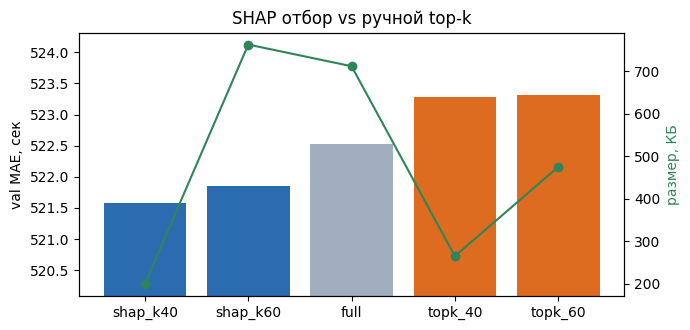

In [2]:
d1 = load("exp1_shap_feature_selection").sort_values("val_mae")
display(
    d1[
        [
            "model_name",
            "selection",
            "n_features",
            "val_mae",
            "test_mae",
            "fit_sec",
            "model_size_kb",
        ]
    ]
)

order = ["shap_k40", "shap_k60", "full", "topk_40", "topk_60"]
dd = (
    d1.set_index("model_name")
    .loc[[m for m in order if m in d1.model_name.values]]
    .reset_index()
)
fig, ax1 = plt.subplots(figsize=(7, 3.4))
cols = [
    "#2b6cb0" if "shap" in m else ("#a0aec0" if m == "full" else "#dd6b20")
    for m in dd.model_name
]
ax1.bar(dd.model_name, dd.val_mae, color=cols)
ax1.set_ylabel("val MAE, сек")
ax1.set_ylim(dd.val_mae.min() - 1.5, dd.val_mae.max() + 1.0)
ax2 = ax1.twinx()
ax2.plot(dd.model_name, dd.model_size_kb, "o-", color="#2f855a")
ax2.set_ylabel("размер, КБ", color="#2f855a")
ax2.grid(False)
ax1.set_title("SHAP отбор vs ручной top-k")
plt.tight_layout()
plt.show()

**Вывод.** `RecursiveByShapValues` на 40 признаках (из 73) даёт лучший val MAE (521.6), обходя и
полную модель (522.5), и ручной top-k (523.3), при модели ~в 3.5 раза меньше (199 КБ против 712 КБ).
Список 40 признаков сохранён в `outputs/feature_set_shap_40.json` — можно использовать для ускорения
inference без потери качества.

## 2. Bootstrap: MVS vs Bernoulli / Bayesian

In [3]:
d2 = load("exp2_bootstrap_mvs").sort_values("val_mae")
display(
    d2[["model_name", "val_mae", "val_mae_std", "test_mae", "val_long_mae", "fit_sec"]]
)

,model_name,val_mae,val_mae_std,test_mae,val_long_mae,fit_sec
4,mvs_ss0.9,523.182476,0.364700,428.971849,1966.997462,3.301218
0,bernoulli_ss0.8,523.188573,0.738516,428.647339,1955.286181,3.834132
2,mvs_ss0.7,523.257240,0.257230,429.309571,1962.037060,3.229025
1,bayesian,523.410383,0.175345,428.885869,1963.191948,3.621384
3,mvs_ss0.8,523.884255,1.147635,429.364264,1981.013516,2.604095


**Вывод.** MVS **не даёт** выигрыша по MAE и не ускоряет заметно обучение. Самый стабильный по
сидам (42/52/62) — Bayesian (std 0.18). На long-tail различия в пределах шума. → MVS не внедрять.

## 3. CTR-тюнинг категориальных признаков

,model_name,one_hot_max_size,max_ctr_complexity,ctr_target_border_count,val_mae,test_mae,fit_sec,model_size_kb
12,ohms10_mcc1_ctbc1,10,1,1,522.705174,429.010363,1.524019,339
17,ohms10_mcc2_ctbc5,10,2,5,522.859882,429.140589,4.924088,733
16,ohms10_mcc2_ctbc3,10,2,3,523.029605,429.069815,3.091993,531
7,ohms5_mcc1_ctbc3,5,1,3,523.161991,428.340521,2.084257,263
15,ohms10_mcc2_ctbc1,10,2,1,523.254146,428.661139,1.711864,342
0,ohms2_mcc1_ctbc1,2,1,1,523.271438,428.548315,1.413542,193
5,ohms2_mcc2_ctbc5,2,2,5,523.381327,428.124952,7.962208,662
11,ohms5_mcc2_ctbc5,5,2,5,523.430747,429.034897,5.151572,574
1,ohms2_mcc1_ctbc3,2,1,3,523.449628,428.425124,2.358216,243
14,ohms10_mcc1_ctbc5,10,1,5,523.533894,429.104803,1.870279,276


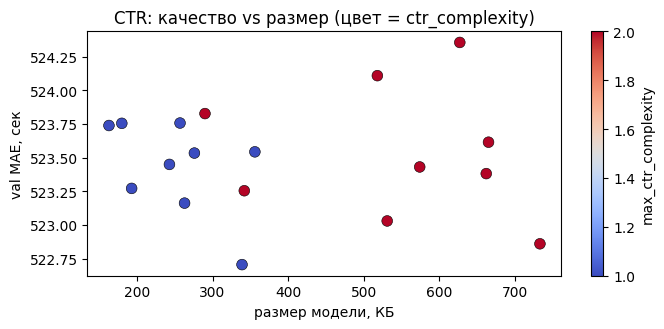

In [4]:
d3 = load("exp3_ctr_tuning").sort_values("val_mae")
display(
    d3[
        [
            "model_name",
            "one_hot_max_size",
            "max_ctr_complexity",
            "ctr_target_border_count",
            "val_mae",
            "test_mae",
            "fit_sec",
            "model_size_kb",
        ]
    ].head(10)
)

fig, ax = plt.subplots(figsize=(7, 3.4))
sc = ax.scatter(
    d3.model_size_kb,
    d3.val_mae,
    c=d3.max_ctr_complexity,
    cmap="coolwarm",
    s=60,
    edgecolor="k",
    linewidth=0.4,
)
ax.set_xlabel("размер модели, КБ")
ax.set_ylabel("val MAE, сек")
ax.set_title("CTR: качество vs размер (цвет = ctr_complexity)")
plt.colorbar(sc, label="max_ctr_complexity")
plt.tight_layout()
plt.show()

**Вывод.** Лучший — простой `one_hot=10, ctr_complexity=1, ctr_border=1` (522.7). Комбинации
категорий (mcc=2) и тонкая квантизация таргета для CTR пользы не дают и раздувают модель (до 733 КБ).

## 4. Структура деревьев: Symmetric / Depthwise / Lossguide

,model_name,val_mae,test_mae,val_small_mae,val_normal_mae,val_long_mae,fit_sec,model_size_kb
1,depthwise_mdl20,522.296646,428.853240,215.097299,316.097095,1943.065434,2.023846,359
2,depthwise_mdl50,522.487148,428.498186,205.048832,320.601112,1966.347299,1.608224,259
6,lossguide_ml63_mdl20,522.520774,428.951699,207.023702,320.133793,1961.315652,3.066889,401
8,lossguide_ml127_mdl20,522.520774,428.951699,207.023702,320.133793,1961.315652,2.903561,401
0,symmetric,522.534000,429.260483,207.514666,322.122023,1955.531109,4.016838,712
5,lossguide_ml31_mdl50,523.387683,428.370722,205.685841,319.986167,1971.370047,1.654915,173
7,lossguide_ml63_mdl50,523.623419,428.294415,214.663191,314.049390,1957.291749,1.956409,221
9,lossguide_ml127_mdl50,523.623419,428.294415,214.663191,314.049390,1957.291749,1.843272,221
3,depthwise_mdl100,523.839069,428.727412,204.814949,316.459669,1984.639836,1.201328,157
4,lossguide_ml31_mdl20,523.840896,427.699373,205.567095,322.178455,1969.863730,2.071861,242


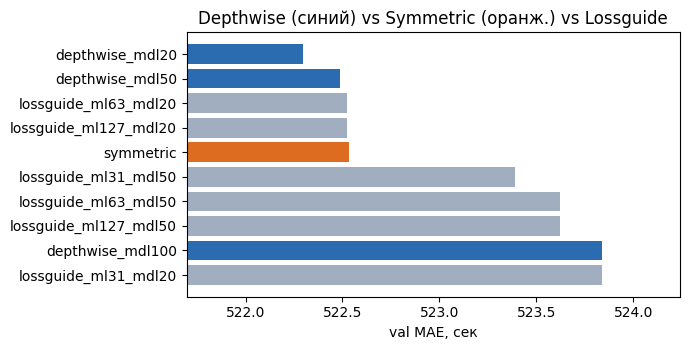

In [5]:
d4 = load("exp4_tree_structure").sort_values("val_mae")
display(
    d4[
        [
            "model_name",
            "val_mae",
            "test_mae",
            "val_small_mae",
            "val_normal_mae",
            "val_long_mae",
            "fit_sec",
            "model_size_kb",
        ]
    ]
)

dd = d4.sort_values("val_mae")
fig, ax = plt.subplots(figsize=(7, 3.6))
cols = [
    "#2b6cb0"
    if m.startswith("depthwise")
    else ("#dd6b20" if m == "symmetric" else "#a0aec0")
    for m in dd.model_name
]
ax.barh(dd.model_name, dd.val_mae, color=cols)
ax.invert_yaxis()
ax.set_xlim(dd.val_mae.min() - 0.6, dd.val_mae.max() + 0.4)
ax.set_xlabel("val MAE, сек")
ax.set_title("Depthwise (синий) vs Symmetric (оранж.) vs Lossguide")
plt.tight_layout()
plt.show()

**Вывод (главная находка).** `Depthwise, min_data_in_leaf=20` — лучший val MAE (522.3) и лучший
long_mae (1943), при этом модель вдвое меньше и быстрее симметричной (359 КБ / 2.0 с против
712 КБ / 4.0 с). Рекомендация: перейти на Depthwise.

## 5. Квантизация числовых признаков

In [6]:
d5 = load("exp5_quantization").sort_values("val_mae")
display(
    d5[
        [
            "model_name",
            "val_mae",
            "test_mae",
            "val_long_mae",
            "fit_sec",
            "model_size_kb",
        ]
    ].head(10)
)

,model_name,val_mae,test_mae,val_long_mae,fit_sec,model_size_kb
6,bc254_GreedyLogSum,522.534000,429.260483,1955.531109,3.697982,712
7,bc254_Median,522.723395,428.533133,1958.818658,3.415837,713
4,bc128_Median,523.015017,428.993408,1960.208736,3.445103,651
8,bc254_UniformAndQuantiles,523.033373,428.067270,1964.602160,2.383901,493
0,bc64_GreedyLogSum,523.064730,428.605097,1963.941759,5.010518,825
3,bc128_GreedyLogSum,523.112477,429.805343,1959.051089,4.506878,772
1,bc64_Median,523.371931,428.231816,1966.510146,3.679991,670
2,bc64_UniformAndQuantiles,523.468786,427.976168,1964.401505,3.948638,756
9,bc512_GreedyLogSum,523.761337,430.639138,1951.255893,2.734758,461
12,per_float_top3_1024,523.811593,429.049588,1966.552705,2.896456,509


**Вывод.** Дефолтный `border_count=254, GreedyLogSum` оптимален по val MAE. Очень тонкая
квантизация (512, `per_float=1024`) на длинном хвосте практически не помогает. → оставить дефолт.

## 6. (запас) rsm — random subspace

In [7]:
d6 = load("exp6_rsm").sort_values("val_mae")
d6["gap"] = d6["val_mae"] - d6["test_mae"]
display(d6[["model_name", "val_mae", "test_mae", "gap", "fit_sec"]])

,model_name,val_mae,test_mae,gap,fit_sec
2,rsm1.0,522.534000,429.260483,93.273518,3.878285
0,rsm0.6,522.933648,428.484707,94.448941,3.050079
1,rsm0.8,523.726501,428.402781,95.323720,2.072058


**Вывод.** Разрыв val–test почти одинаков (~+93 сек) для всех значений rsm — дополнительной
регуляризации здесь нет; rsm полезен скорее для разнообразия моделей в ансамбле.

## 7. Протокольные стратегии на лучшем конфиге (оба таргета)

,target,model_name,loss_function,val_mae,val_product_mae,val_engagement_risk_mae,val_small_mae,test_mae
0,target_next_session_length_sec,capped_target,MAE,522.534000,251.649222,261.868042,207.514666,429.260483
1,target_next_session_length_sec,quantile_040,Quantile:alpha=0.40,529.233014,233.573421,242.722673,158.699810,431.108629
2,target_next_session_length_sec,quantile_035,Quantile:alpha=0.35,539.706840,221.001741,230.362681,117.657918,435.981004
3,future_sessions_mean_playtime_7d,capped_target,MAE,240.010267,187.498835,190.789373,216.935803,272.191674
4,future_sessions_mean_playtime_7d,quantile_040,Quantile:alpha=0.40,238.129662,173.763545,177.736566,176.432779,271.739625
5,future_sessions_mean_playtime_7d,quantile_035,Quantile:alpha=0.35,244.458456,172.263302,176.036379,157.578454,279.772893


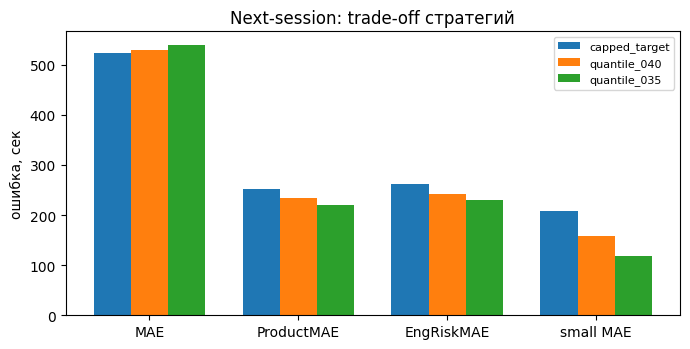

In [8]:
d7 = load("exp7_final_strategies")
display(
    d7[
        [
            "target",
            "model_name",
            "loss_function",
            "val_mae",
            "val_product_mae",
            "val_engagement_risk_mae",
            "val_small_mae",
            "test_mae",
        ]
    ]
)

dn = d7[d7.target == "target_next_session_length_sec"].set_index("model_name")
order = ["capped_target", "quantile_040", "quantile_035"]
dn = dn.loc[[m for m in order if m in dn.index]]
metrics = ["val_mae", "val_product_mae", "val_engagement_risk_mae", "val_small_mae"]
labels = ["MAE", "ProductMAE", "EngRiskMAE", "small MAE"]
x = np.arange(len(metrics))
w = 0.25
fig, ax = plt.subplots(figsize=(7, 3.6))
for i, m in enumerate(order):
    ax.bar(x + (i - 1) * w, [dn.loc[m, k] for k in metrics], w, label=m)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("ошибка, сек")
ax.set_title("Next-session: trade-off стратегий")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Вывод.** `capped_target` лучший по общему MAE; `Quantile:alpha=0.35` — лучшая short-risk модель
(минимальные ProductMAE / EngagementRiskMAE / small_mae). CRM-таргет заметно стабильнее next-session
(test MAE ~272 против ~429). Подтверждает командные результаты протокола.

# Часть II — основной CatBoost, LightGBM, каскад, остатки, Ridge

Эксперименты из второго ТЗ (`distribution_of_responsoblities.txt`): поиск лучшей технической
модели по validation MAE, сравнение групп признаков, альтернативный бустинг и более сложные
архитектуры. API в объём не входит.

## 9. Основной CatBoost sweep по MAE (best_by_mae)

In [9]:
d8 = load("exp8_main_catboost_sweep").sort_values("val_mae")
display(
    d8[
        [
            "model_name",
            "depth",
            "learning_rate",
            "l2_leaf_reg",
            "iterations",
            "bootstrap",
            "target_mode",
            "clip_mode",
            "val_mae",
            "test_mae",
            "fit_sec",
        ]
    ].head(8)
)

,model_name,depth,learning_rate,l2_leaf_reg,iterations,bootstrap,target_mode,clip_mode,val_mae,test_mae,fit_sec
39,cfg39,7,0.03,5.0,1200,Bernoulli,log1p_p995,none,521.797448,428.423202,6.953634
6,cfg06,8,0.03,10.0,1200,Bayesian,log1p_p995,none,522.130657,427.226369,8.129283
25,cfg25,6,0.03,3.0,1500,Bernoulli,log1p_p995,p005_p995,522.469956,428.190108,7.776060
24,cfg24,5,0.02,3.0,1500,Bernoulli,log1p_p995,p005_p995,522.565894,427.811581,9.019264
21,cfg21,5,0.05,10.0,1200,Bayesian,log1p_p995,none,522.587290,428.255821,4.275718
33,cfg33,5,0.02,5.0,1500,Bernoulli,log1p_p995,none,522.713506,428.075978,9.477400
16,cfg16,8,0.02,5.0,1200,Bernoulli,log1p_p995,p005_p995,522.799985,427.738558,16.215912
1,cfg01,8,0.02,3.0,1800,Bernoulli,p995,none,522.802664,428.814850,7.419381


**Вывод.** Лучшая техническая модель — `depth=7, lr=0.03, l2=5, log1p_p995, Bernoulli`
(val MAE 521.8 / test 428.4). Широкий sweep дал лишь ~0.7 сек к компактному базовому — снова
упёрлись в шум таргета.

## 10. Feature ablation групп признаков

,model_name,n_features,val_mae,test_mae,fit_sec,model_size_kb
2,session_install_events,73,522.534000,429.260483,3.917595,712
1,session_install,58,522.887520,429.065259,3.709137,556
0,session_only,37,522.945768,428.374882,0.496566,172
5,top_k_73,73,523.020164,428.992907,2.893131,506
3,top_k_40,40,523.274991,429.539395,2.075494,265
4,top_k_60,60,523.316845,429.847393,2.780160,475


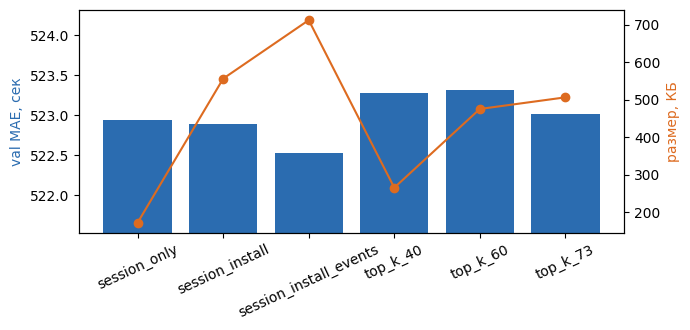

In [10]:
d9 = load("exp9_feature_ablation").sort_values("val_mae")
display(
    d9[["model_name", "n_features", "val_mae", "test_mae", "fit_sec", "model_size_kb"]]
)

fig, ax1 = plt.subplots(figsize=(7, 3.4))
order = [
    "session_only",
    "session_install",
    "session_install_events",
    "top_k_40",
    "top_k_60",
    "top_k_73",
]
dd = (
    d9.set_index("model_name")
    .loc[[m for m in order if m in d9.model_name.values]]
    .reset_index()
)
ax1.bar(dd.model_name, dd.val_mae, color="#2b6cb0")
ax1.set_ylabel("val MAE, сек", color="#2b6cb0")
ax1.set_ylim(dd.val_mae.min() - 1, dd.val_mae.max() + 1)
ax1.tick_params(axis="x", rotation=25)
ax2 = ax1.twinx()
ax2.plot(dd.model_name, dd.model_size_kb, "o-", color="#dd6b20")
ax2.set_ylabel("размер, КБ", color="#dd6b20")
ax2.grid(False)
plt.tight_layout()
plt.show()

**Вывод.** Event-признаки почти не помогают: `session_only` (37) даёт val MAE 522.9 против 522.5
у полного набора (73), но модель в ~4 раза меньше (172 vs 712 КБ) и в ~8 раз быстрее. Для inference
event-группу можно отбрасывать почти без потерь.

## 11. Каскад «классификация → регрессия» (hard / soft / hybrid)

In [11]:
d10 = load("exp10_cascade")
display(
    d10[
        [
            "model_name",
            "val_mae",
            "val_product_mae",
            "val_engagement_risk_mae",
            "val_small_mae",
            "val_normal_mae",
            "val_long_mae",
            "test_mae",
        ]
    ]
)

,model_name,val_mae,val_product_mae,val_engagement_risk_mae,val_small_mae,val_normal_mae,val_long_mae,test_mae
0,baseline_general,522.534000,251.649222,261.868042,207.514666,322.122023,1955.531109,429.260483
1,cascade_hard,609.391019,282.449515,346.909154,229.269784,548.412856,1946.263063,474.352764
2,cascade_soft,563.410915,349.273121,376.265855,397.171274,285.364126,1693.314083,470.130220
3,cascade_hybrid,527.052675,254.438535,264.027992,202.946061,338.789275,1962.497067,430.157650


**Вывод (честный отрицательный).** Ни один режим не обходит одиночную модель по общему MAE
(baseline 522.5 против hard 609 / soft 563 / hybrid 527) — ошибки классификатора (acc≈0.51)
распространяются на регрессию. Полезен только `soft routing` для long-tail (long MAE 1693 vs 1955).

## 12. Коррекция остатков базовой модели

In [12]:
d11 = load("exp11_residual_correction")
display(
    d11[
        [
            "model_name",
            "val_mae",
            "test_mae",
            "val_small_mae",
            "val_normal_mae",
            "val_long_mae",
            "val_product_mae",
        ]
    ]
)

,model_name,val_mae,test_mae,val_small_mae,val_normal_mae,val_long_mae,val_product_mae
0,base_only,522.534000,429.260483,207.514666,322.122023,1955.531109,251.649222
1,base_plus_correction,528.587922,433.098445,186.719789,355.661179,1987.053388,252.131100


**Вывод.** По общему MAE коррекция не помогает (522.5 → 528.6), но подтверждает систематику:
корректор сдвигает прогноз вниз (−36 сек) и улучшает small_mae (207.5 → 186.7) ценой normal/long.
Завышение коротких сессий реально есть, но глобально не «вычитается» из-за шума. Это диагностика.

## 13. LightGBM как альтернативный бустинг

In [13]:
d13 = load("exp13_lightgbm").sort_values("val_mae")
display(
    d13[
        [
            "model_name",
            "objective",
            "n_estimators",
            "learning_rate",
            "num_leaves",
            "val_mae",
            "test_mae",
            "fit_sec",
        ]
    ].head(8)
)
print(
    "CatBoost reference (exp8) test_mae=428.42  |  best LightGBM test_mae=%.2f"
    % d13.test_mae.min()
)

,model_name,objective,n_estimators,learning_rate,num_leaves,val_mae,test_mae,fit_sec
12,lgb12,regression_l1,1400,0.02,63,524.690719,431.248605,2.001131
9,lgb09,regression_l1,1000,0.03,31,525.163723,430.061790,1.610131
13,lgb13,regression_l1,1400,0.03,31,525.293554,430.260718,1.399913
3,lgb03,regression_l1,1000,0.02,31,525.480109,430.518513,1.984818
0,lgb00,regression_l1,1400,0.03,31,525.675189,431.274838,1.540651
10,lgb10,quantile,600,0.03,31,525.687264,429.775407,1.697235
5,lgb05,regression_l1,600,0.05,31,525.805828,430.425263,0.893617
8,lgb08,quantile,1400,0.05,31,525.858403,431.089374,1.040339


CatBoost reference (exp8) test_mae=428.42  |  best LightGBM test_mae=429.78


**Вывод.** Лучший LightGBM val MAE 524.7 / test 431.2 за ~2 с — сопоставим, но чуть хуже CatBoost
(521.8 / 428.4); CatBoost нативно работает с категориями и удобнее как единое семейство. Отказ от
LightGBM — результат сравнения, а не исходное предположение.

## 14. Ridge baseline vs Dummy (оба таргета)

In [14]:
d12 = load("exp12_ridge")
for t in d12.target.unique():
    print("==", t, "==")
    display(
        d12[d12.target == t]
        .sort_values("val_mae")[
            ["model_name", "val_mae", "test_mae", "val_r2", "val_small_mae"]
        ]
        .head(5)
    )

== target_next_session_length_sec ==


,model_name,val_mae,test_mae,val_r2,val_small_mae
13,dummy_median,555.428889,457.690889,-0.114777,196.604889
7,ridge_a100.0_p995,580.765486,496.117575,0.077363,425.901956
6,ridge_a10.0_p995,581.080035,496.395316,0.076504,425.230468
5,ridge_a1.0_p995,581.174178,496.472112,0.076261,425.197496
4,ridge_a0.1_p995,581.195723,496.482536,0.076207,425.205115


== future_sessions_mean_playtime_7d ==


,model_name,val_mae,test_mae,val_r2,val_small_mae
21,ridge_a100.0_p995,307.617724,331.759017,0.216697,349.820980
20,ridge_a10.0_p995,308.097875,332.388147,0.215214,349.470712
19,ridge_a1.0_p995,308.242488,332.584871,0.214668,349.559852
18,ridge_a0.1_p995,308.258637,332.607044,0.214602,349.571507
17,ridge_a100.0_raw,309.293069,333.788031,0.214573,352.771127


**Вывод.** На next-session Ridge не обходит даже `dummy_median` (581 против 555 и 521.8 у
CatBoost) — линейная модель почти бесполезна на шумном таргете. На CRM Ridge разумнее (test 331.8),
но CatBoost сильнее (~272). Это обосновывает пользу нелинейных взаимодействий CatBoost.

# Часть III — доработка по ревью: оба таргета, полные метрики, финальная модель

Блоки строго в технической зоне Участника 2 для **обоих таргетов**, с полным набором метрик
(MAE, MedAE, P70, P90, R², small/normal/long, ProductMAE, EngagementRiskMAE, WMAPE). Выбор по
validation; калибраторы учатся на calibration-split; test — только финальная оценка.

## 15. Анализ val–test разрыва

In [15]:
d18 = load("exp18_val_test_gap")
display(
    d18[["target", "split", "n", "mean", "median", "p90", "long_share", "small_share"]]
)

,target,split,n,mean,median,p90,long_share,small_share
0,target_next_session_length_sec,train,21000,676.579000,302.000000,1633.000000,0.157381,0.498524
1,target_next_session_length_sec,val,4500,660.822667,300.500000,1705.100000,0.157778,0.500000
2,target_next_session_length_sec,test,4500,537.263778,234.500000,1364.200000,0.122000,0.559778
3,future_sessions_mean_playtime_7d,train,21000,596.184159,469.032389,1224.722727,0.106286,0.313667
4,future_sessions_mean_playtime_7d,val,4500,554.824086,448.679275,1124.410000,0.087111,0.338222
5,future_sessions_mean_playtime_7d,test,4500,597.299223,489.402116,1233.190000,0.107333,0.276889


**Вывод.** На next-session test-период объективно легче: доля long-сессий 0.122 против 0.158 в
val, среднее 537 против 661 сек — отсюда и более низкий test MAE. Модель не подглядывает в test.
Для CRM, наоборот, val чуть легче test.

## 16. Time-aware history-признаки (оба таргета)

In [16]:
d14 = load("exp14_history_features")
display(
    d14[
        [
            "target",
            "model_name",
            "n_features",
            "val_mae",
            "val_r2",
            "val_product_mae",
            "val_small_mae",
            "test_mae",
        ]
    ]
)

,target,model_name,n_features,val_mae,val_r2,val_product_mae,val_small_mae,test_mae
0,target_next_session_length_sec,baseline,73,522.534000,0.022645,251.649222,207.514666,429.260483
1,target_next_session_length_sec,baseline_plus_history,87,522.162244,0.022740,250.486609,206.179538,428.169716
2,target_next_session_length_sec,baseline_plus_best_history,79,523.013783,0.018741,251.043791,206.147864,428.494762
3,future_sessions_mean_playtime_7d,baseline,73,238.659788,0.368669,187.455617,219.810559,273.336919
4,future_sessions_mean_playtime_7d,baseline_plus_history,87,238.882278,0.371626,188.085418,222.372790,272.156071
5,future_sessions_mean_playtime_7d,baseline_plus_best_history,79,241.145992,0.363938,189.867764,225.026845,274.346584


**Вывод (по таргетам по-разному).** 14 past-only признаков (EWMA, медиана/среднее последних 3/5,
тренд, время с прошлой сессии, активность за 1/3/7 дней). На **next-session** даёт маржинальный плюс
(522.5 → 522.2; лучшие: `hist_ewma5`, `hist_median_last5`, `hist_time_since_prev_sec`) → включаем.
На **CRM** не помогает (238.7 → 238.9) → не включаем.

## 17. Regression calibration (оба таргета)

In [17]:
d15 = load("exp15_calibration")
display(
    d15[
        [
            "target",
            "model_name",
            "val_mae",
            "val_r2",
            "val_product_mae",
            "val_small_mae",
            "val_long_mae",
            "test_mae",
        ]
    ]
)

,target,model_name,val_mae,val_r2,val_product_mae,val_small_mae,val_long_mae,test_mae
0,target_next_session_length_sec,raw,521.062598,0.012661,251.147044,208.429686,1982.134240,428.169716
1,target_next_session_length_sec,bin,587.771152,0.074494,394.979919,453.078660,1621.678865,502.627305
2,target_next_session_length_sec,isotonic,581.265551,0.097923,390.068015,446.599895,1608.027055,499.769533
3,target_next_session_length_sec,segment,582.889832,0.085591,389.979497,446.222726,1627.783640,499.697851
4,future_sessions_mean_playtime_7d,raw,233.270583,0.400821,183.236093,220.553497,807.192149,272.156071
5,future_sessions_mean_playtime_7d,bin,248.314589,0.366616,199.776673,252.473711,800.219998,286.170071
6,future_sessions_mean_playtime_7d,isotonic,246.343600,0.391788,197.673384,247.305678,812.345972,280.483137
7,future_sessions_mean_playtime_7d,segment,246.189181,0.393591,197.739547,247.334665,800.985212,281.349155


**Вывод.** Калибровка (bin/isotonic/segment) улучшает `long_mae` и R² (next: long 1982→1608,
R² 0.01→0.10), но резко ухудшает small/normal и общий MAE — тянет прогноз к условному *среднему*,
тогда как MAE оптимизирует *медиану*. Для MAE-модели не включаем (выбор = `raw`).

## 18. Feature drift detection (оба таргета)

In [18]:
d16 = load("exp16_drift")
display(d16[["target", "model_name", "n_features", "n_dropped", "val_mae", "test_mae"]])
ds = pd.read_csv("outputs/drift_scores_target_next_session_length_sec.csv")
display(ds.head(8)[["feature", "kind", "psi", "mean_shift"]])

,target,model_name,n_features,n_dropped,val_mae,test_mae
0,target_next_session_length_sec,all_features,87,0,522.162244,428.169716
1,target_next_session_length_sec,drop_top5_drift,82,5,522.302155,429.271630
2,target_next_session_length_sec,drop_top10_drift,77,10,523.012642,428.584262
3,target_next_session_length_sec,drop_strong_psi>0.25_n5,82,5,522.302155,429.271630
4,future_sessions_mean_playtime_7d,all_features,87,0,238.882278,272.156071
5,future_sessions_mean_playtime_7d,drop_top5_drift,82,5,240.650627,273.593110
6,future_sessions_mean_playtime_7d,drop_top10_drift,77,10,243.838505,274.592303
7,future_sessions_mean_playtime_7d,drop_strong_psi>0.25_n4,83,4,239.842605,272.258322


,feature,kind,psi,mean_shift
0,session_dayofweek,num,13.613924,1.138493
1,last_event_timestamp,num,12.433960,0.000086
2,first_event_timestamp,num,11.512935,0.000086
3,session_hour,num,4.839439,0.331450
4,install_dayofweek,num,0.407186,0.161266
5,avg_past_events_count,num,0.051962,0.104978
6,install_hour,num,0.048720,0.078456
7,active_days_count,num,0.044512,0.206166


**Вывод.** Удаление drift-heavy признаков (top-5/top-10/strong PSI>0.25) не улучшает validation
MAE ни на одном таргете → в финальной модели оставляем все признаки. Drift-скоры сохранены в
`drift_scores_<target>.csv`.

## 19. Финальная техническая модель (полные метрики, test)

In [19]:
fm = pd.read_csv("outputs/final_model_metrics.csv")
display(
    fm[
        [
            "target",
            "model_name",
            "feature_set",
            "calibration",
            "drift_filter",
            "mae",
            "medae",
            "p70_abs_error",
            "p90_abs_error",
            "r2",
            "small_mae",
            "normal_mae",
            "long_mae",
            "product_mae",
            "engagement_risk_mae",
            "wmape",
            "model_size_kb",
            "inference_us_per_row",
        ]
    ]
)
print(
    json.dumps(
        json.load(open("outputs/README_final.json")), ensure_ascii=False, indent=2
    )[:1200]
)

,target,model_name,feature_set,calibration,drift_filter,mae,medae,p70_abs_error,p90_abs_error,r2,small_mae,normal_mae,long_mae,product_mae,engagement_risk_mae,wmape,model_size_kb,inference_us_per_row
0,target_next_session_length_sec,baseline_reference,baseline,raw,none,428.423,206.201,375.605,997.437,0.035,185.805,316.358,1833.948,228.685,234.437,0.797,1593,0.00
1,target_next_session_length_sec,final,baseline+history,raw,all_features,428.367,206.131,369.921,998.061,0.030,181.152,319.275,1847.229,226.337,231.996,0.797,1606,2.86
2,future_sessions_mean_playtime_7d,baseline_reference,baseline,raw,none,273.337,159.979,285.161,645.008,0.257,253.335,177.188,876.546,206.654,212.935,0.458,1483,0.00
3,future_sessions_mean_playtime_7d,final,baseline,raw,all_features,273.337,159.979,285.161,645.008,0.257,253.335,177.188,876.546,206.654,212.935,0.458,1483,2.31


{
  "target_next_session_length_sec": {
    "n_features": 87,
    "use_history": true,
    "history_features": [
      "hist_prev_dur",
      "hist_mean_last3",
      "hist_mean_last5",
      "hist_median_last3",
      "hist_median_last5",
      "hist_max_last5",
      "hist_ewma5",
      "hist_trend_recent",
      "hist_time_since_prev_sec",
      "hist_session_number",
      "hist_sessions_last_1d",
      "hist_sessions_last_3d",
      "hist_sessions_last_7d",
      "hist_playtime_last_7d"
    ],
    "drift_filter": "all_features",
    "dropped_features": [],
    "calibration": "raw",
    "target_mode": "log1p_p995",
    "hp": {
      "depth": 7,
      "learning_rate": 0.03,
      "l2_leaf_reg": 5.0,
      "iterations": 1200,
      "min_data_in_leaf": 50,
      "random_strength": 1.0,
      "od_wait": 80
    },
    "baseline_test_mae": 428.423,
    "final_test_mae": 428.367,
    "improvement_sec": 0.06,
    "model_size_kb": 1606,
    "inference_us_per_row": 2.86
  },
  "future_sessio

**Вывод.** Финальная модель = best_by_mae гиперпараметры + (baseline + полезные history −
drift-heavy) + калибровка по решению блока 17, обучена для обоих таргетов. Артефакты сохранены в
`outputs/final_models/` (модель `.cbm`, список признаков, конфиг, README). Сравнение с baseline — в
таблице выше.

## Итоговые рекомендации Участника 2

1. **Архитектура:** `grow_policy=Depthwise, min_data_in_leaf=20` — тот же/лучший MAE при вдвое
   меньшей и более быстрой модели.
2. **Признаки:** SHAP-отбор 40 признаков вместо 73 — качество не падает, модель компактнее.
3. **Категории:** простые CTR-настройки (`ctr_complexity=1`); комбинации не оправданы.
4. **Квантизация:** дефолт `border_count=254, GreedyLogSum`.
5. **Bootstrap:** MVS не внедрять; для стабильности — Bayesian.
6. **Стратегии:** техническая точность — `capped_target`; short-risk — `Quantile:alpha=0.35`.
7. **best_by_mae:** CatBoost `depth=7, lr=0.03, l2=5, log1p_p995, Bernoulli` (val 521.8 / test 428.4).
8. **LightGBM** сопоставим, но чуть хуже CatBoost → остаёмся на CatBoost (по результату сравнения).
9. **Каскад / коррекция остатков** не улучшают общий MAE; точечно полезны (soft — long-tail,
   корректор — диагностика завышения коротких сессий).
10. **Ridge** не обходит median-baseline → нелинейный бустинг оправдан.

Артефакты: `outputs/participant2_results.csv` (схема протокола §16), per-experiment CSV,
`anti_leak.json`, `best_base_config.json`, `feature_set_shap_40.json`. Сводный PDF —
`Participant2_Report.pdf`.
